# Notebook 1

## Shapedata

In [7]:
from bootstrap import *
from pathlib import Path 
import geopandas as gpd

from src import PathManager

In [66]:
pm                  = PathManager()
raw_shapedata       = pm.data / 'raw' / 'shapedata'

from dataclasses import dataclass 
from typing import Self
from tqdm import tqdm
import pandas as pd

@dataclass
class Countryshp:
    name: str
    code: str
    shp: gpd.GeoDataFrame

    def __repr__(self) -> str:
        return f"<{self.__class__.__name__}({self.name})>"

@dataclass
class Countryrawshp:
    name: str
    code: str
    admin0: gpd.GeoDataFrame 
    admin1: gpd.GeoDataFrame
    admin2: gpd.GeoDataFrame

    def process(self) -> Self:

        gdf_merged = gpd.GeoDataFrame(
            pd.concat([
                self._lowercase(self._select_cols(self._rename_cols(self.admin0))),
                self._lowercase(self._select_cols(self._rename_cols(self.admin1))),
                self._lowercase(self._select_cols(self._rename_cols(self.admin2)))
            ]))

        return Countryshp(
            self.name,
            self.code,
            gdf_merged

        )
    def _rename_cols(self, gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
        columns_mapping = {
            'shapeName' : 'name',
            'shapeType' : 'admin_level',
            'shapeGroup': 'country'
        }
        return gdf.rename(columns = columns_mapping)

    def _select_cols(self, gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
        columns = ['country','name','admin_level','geometry']
        return gdf[columns]

    def _lowercase(self, gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
        gdf['country']      = gdf['country'].str.lower()
        gdf['name']         = gdf['name'].str.lower()
        gdf['admin_level']  = gdf['admin_level'].str.lower()
        return gdf
                
    
    def __repr__(self) -> str:
        return f"<{self.__class__.__name__}({self.name})>"

countries_dict = {
    'drc'           : 'cod',
    'burundi'       : 'bdi',
    'rwanda'        : 'rwa',
    'south_sudan'   : 'ssd',
    'uganda'        : 'uga'
}

admin_levels                                = [0, 1, 2]
countryshapes_raw: list[Countryrawshp]      = []
countryshapes: list[Countryshp]             = []

for countryname, countrycode in tqdm(countries_dict.items()):
    path        = raw_shapedata / countryname 
    file_base   = 'geoBoundaries-' + countrycode.upper()

    shp = Countryrawshp(
        countryname, 
        countrycode,
        gpd.read_file(path / (file_base + "-" + "ADM0.shp")),           
        gpd.read_file(path / (file_base + "-" + "ADM1.shp")),         
        gpd.read_file(path / (file_base + "-" + "ADM2.shp"))                      
    )

    countryshapes_raw.append(shp)

countryshapes = [gdf.process() for gdf in countryshapes_raw]

100%|██████████| 5/5 [00:01<00:00,  4.74it/s]


C:\Users\de-schrijvers\AppData\Local\Temp\ipykernel_10260\1046632345.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(countries))


<Axes: >

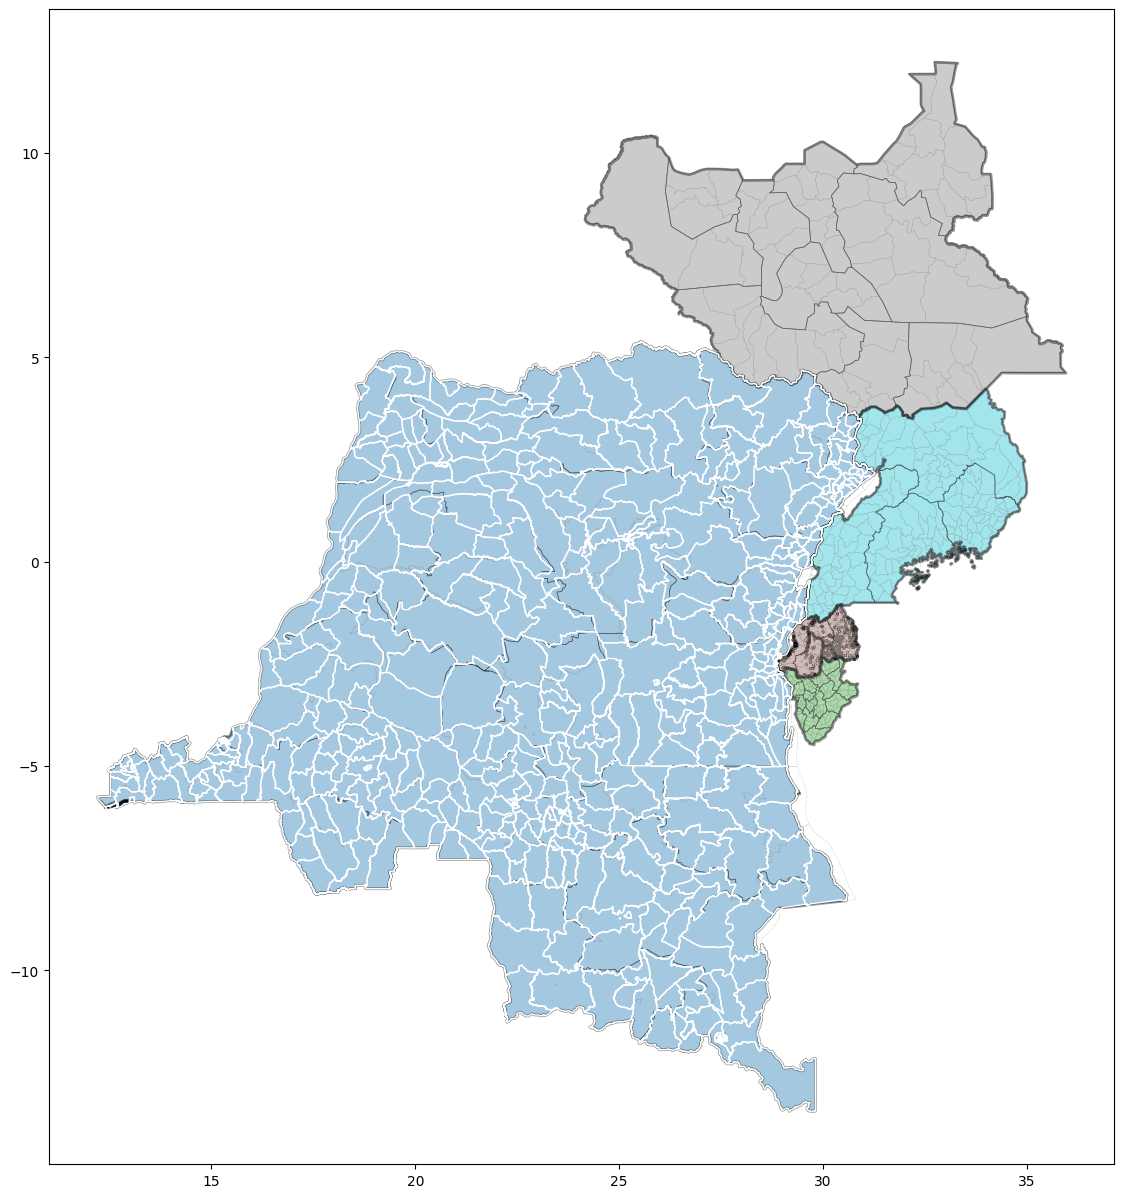

In [72]:
import matplotlib.pyplot as plt 
import matplotlib.cm as cm

fig, ax = plt.subplots(1,1,figsize = (15,15))

admin_levels    = ['adm0', 'adm1', 'adm2']

# Get unique countries
countries = list(countries_dict.keys())

# Assign a distinct color to each country
cmap = cm.get_cmap('tab10', len(countries))
country_colors = {
    country: cmap(i)
    for i, country in enumerate(countries)
}

geomap_args = {
    'adm0' : {'facecolor'   : 'none',
              'edgecolor'   : 'black',
              'linewidth'   : 2},
    'adm1' : {'facecolor'   : 'none',
              'edgecolor'   : 'black',
              'linewidth'   : 0.5},
    'adm2' : {'facecolor'   : 'none',
              'edgecolor'   : 'grey',
              'linewidth'   : 0.25},              
}

for admin_lvl in admin_levels:

    for country_shape in countryshapes:

        sub_section = country_shape.shp[country_shape.shp['admin_level'] == admin_lvl]
        map_args    = geomap_args[admin_lvl]
    
        if admin_lvl == 'adm0':
            map_args = {**map_args, 'facecolor': country_colors[country_shape.name]}

        sub_section.plot(
            ax=ax,
            **map_args,
            alpha = 0.4
        )

hz = gpd.read_file(pm.data / 'raw' /'shapedata'/'osm_rdc_sante_zones_211212.gpkg')

hz.plot(ax = ax, edgecolor = 'white',facecolor = 'none')

In [83]:
cases = pd.read_csv(pm.data/ 'raw' / 'drc_zones_timeseries-zonal-2.csv', parse_dates=['Date'])

<Axes: xlabel='Date', ylabel='Confirmed Cases'>

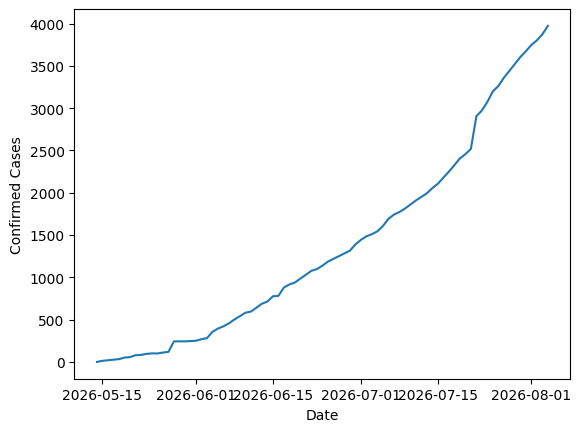

In [84]:
import seaborn as sns 

fig, ax = plt.subplots(1,1)

cases_national = cases.groupby(['Date'])['Confirmed Cases'].sum().reset_index(drop = False)

sns.lineplot(cases_national, x = 'Date', y = 'Confirmed Cases', ax = ax)

In [86]:
cases['Health Zone'].nunique()

53

In [88]:
set(cases['Health Zone']) - set(hz['name'])

{'Boma Mangbetu', 'Nia-Nia', 'Wanie-Rukula'}